# Ch9 控制系統中的濾波器(Filters in Control Systems)

**對應原書**:Chapter 9
**軟體替代**:ModelQ 濾波器方塊 → `scipy.signal` 濾波器設計 + 解析相位損失評估

## 學習目標
1. 理解迴路內濾波器的鐵律:**衰減換相位**,而相位就是邊限。
2. 設計低通(壓感測雜訊)與 notch(壓共振,第 16 章會用)。
3. 量化濾波器造成的 PM 損失,學會「濾波頻率至少放在頻寬 5~10 倍以上」的法則。

In [1]:
import sys, pathlib
sys.path.append(str(pathlib.Path('..').resolve()))
import numpy as np
import matplotlib.pyplot as plt
import control as ct
from common.control_helpers import (first_order, second_order, integrator, inertia,
                                    pi, pid, closed_loop, margins, step_metrics, bandwidth_hz)
from common.sim import (DiscretePID, MotorPlant, DCMotorPlant, TwoMassPlant,
                        Backlash, EncoderModel, Delay, saturate, quantize, coulomb)
from common.dsa import chirp_excitation, prbs_excitation, measure_frf, frf_of_system
from common.plots import bode_compare
np.set_printoptions(precision=4, suppress=True)

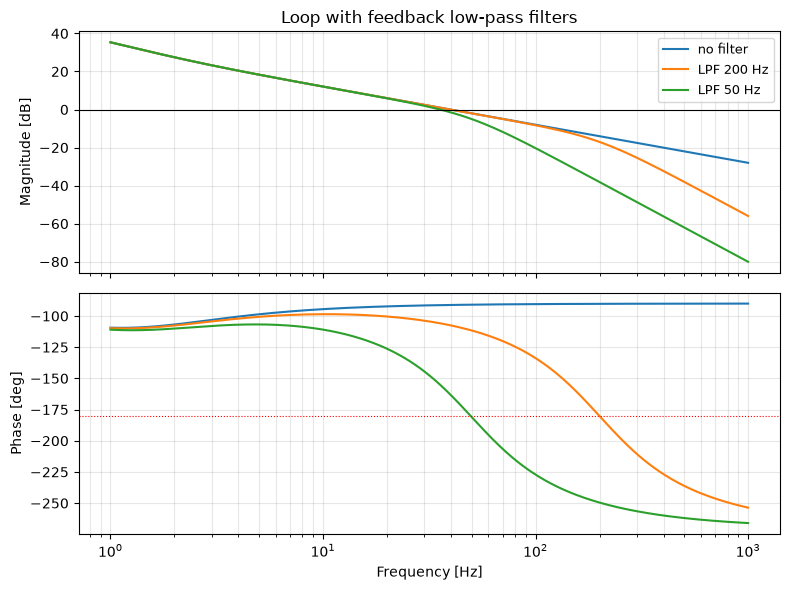

PM 比較(迴路頻寬 ~40 Hz):
  no filter    PM =   88.9°
  LPF 200 Hz   PM =   72.5°
  LPF 50 Hz    PM =   24.9°


In [2]:
from scipy import signal

J, b = 0.002, 0.01
P = inertia(J=J, b=b)
C = pi(kp=0.5, ki=5.0)

def butter2_tf(fc_hz):
    bb, aa = signal.butter(2, 2 * np.pi * fc_hz, 'low', analog=True)
    return ct.tf(bb, aa)

pm_table = {'no filter': margins(C * P)['pm_deg']}
items = [('no filter', C * P)]
for fc in [200, 50]:
    F = butter2_tf(fc)
    pm_table[f'LPF {fc} Hz'] = margins(C * P * F)['pm_deg']
    items.append((f'LPF {fc} Hz', C * P * F))

fig, (axm, axp) = bode_compare(items, f_hz=np.logspace(0, 3, 500),
                               title='Loop with feedback low-pass filters')
axm.axhline(0, color='k', lw=0.8); axp.axhline(-180, color='r', ls=':', lw=0.8)
plt.show()
print('PM 比較(迴路頻寬 ~40 Hz):')
for k, v in pm_table.items():
    print(f'  {k:<12} PM = {v:6.1f}°')

交越頻率約 40 Hz:
- 200 Hz LPF(頻寬的 5 倍)→ PM 損失約 16°,可接受。
- 50 Hz LPF(頻寬的 1.2 倍)→ PM 掉到 ~25°、GM 只剩 ~5 dB,迴路瀕臨不穩。

## Notch 濾波器

Notch 只在目標頻率附近挖洞,遠離該頻率時相位快速恢復
—— 這是它比低通更適合對付「已知頻率共振」的原因。

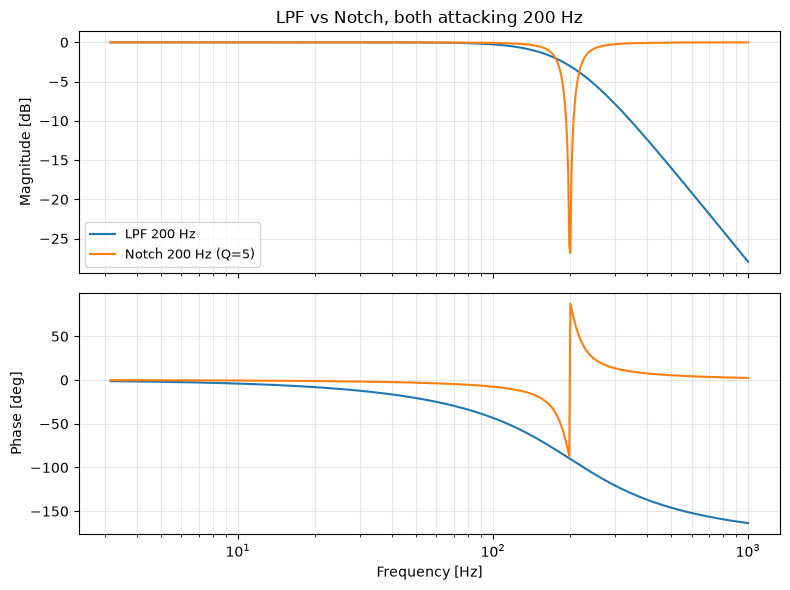

notch 深度 @200 Hz ≈ -inf dB
PM: LPF200=72.5° | Notch200=86.5° | 無濾波=88.9°


/Users/rexwang/workspace/control-system-design-guide/common/dsa.py:61: RuntimeWarning: divide by zero encountered in log10
  "mag_db": 20 * np.log10(np.abs(H)),


In [3]:
def notch_tf(f0_hz, Q=5.0):
    w0 = 2 * np.pi * f0_hz
    return ct.tf([1, 0, w0**2], [1, w0 / Q, w0**2])

N = notch_tf(200, Q=5)
pm_notch = margins(C * P * N)['pm_deg']
fig, (axm, axp) = bode_compare([
    ('LPF 200 Hz', butter2_tf(200)),
    ('Notch 200 Hz (Q=5)', N),
], f_hz=np.logspace(0.5, 3, 600), title='LPF vs Notch, both attacking 200 Hz')
plt.show()

d = frf_of_system(N, np.linspace(190, 210, 201))
depth = float(d['mag_db'].min())
print(f'notch 深度 @200 Hz ≈ {depth:.1f} dB')
print(f"PM: LPF200={pm_table['LPF 200 Hz']:.1f}° | Notch200={pm_notch:.1f}° | 無濾波={pm_table['no filter']:.1f}°")

## 離散實作:迴路內的一階低通壓雜訊

回授訊號含 σ=0.05 的量測雜訊。比較「不濾」與「200 Hz 一階低通」的轉矩命令雜訊。

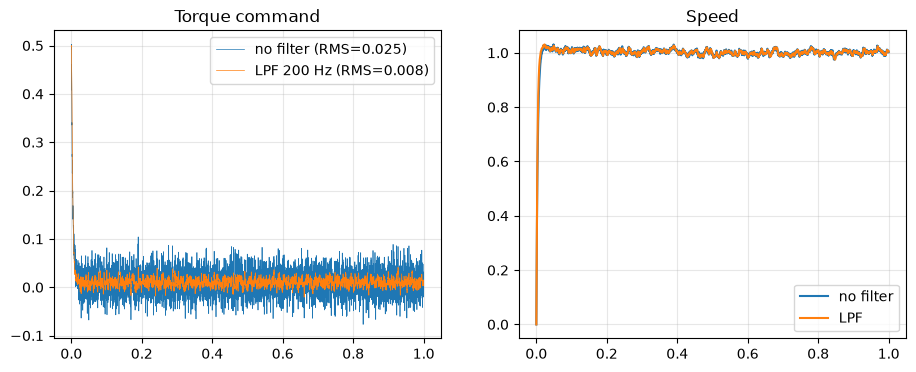

轉矩雜訊 RMS:不濾 0.0251 → 濾波 0.0082(降 3.1 倍)


In [4]:
class OnePole:
    def __init__(self, fc_hz, dt):
        a = 2 * np.pi * fc_hz * dt
        self.alpha, self.y = a / (1 + a), 0.0
    def step(self, x):
        self.y += self.alpha * (x - self.y)
        return self.y

fs = 5000.0
dt = 1 / fs
n = int(1.0 / dt)
rng = np.random.default_rng(42)
noise = rng.normal(0, 0.05, n)

def run(use_filter):
    plant = MotorPlant(J=J, b=b, dt=dt)
    ctrl = DiscretePID(kp=0.5, ki=5.0, dt=dt)
    lpf = OnePole(200, dt)
    u_log, y_log = np.empty(n), np.empty(n)
    for k in range(n):
        y_meas = plant.w + noise[k]
        if use_filter:
            y_meas = lpf.step(y_meas)
        u_log[k] = ctrl.step(1.0 - y_meas)
        y_log[k] = plant.w
        plant.step(u_log[k])
    return u_log, y_log

u_raw, y_raw = run(False)
u_flt, y_flt = run(True)
settle = slice(int(0.5 / dt), n)
rms_raw = float(np.std(u_raw[settle]))
rms_flt = float(np.std(u_flt[settle]))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
tt = np.arange(n) * dt
axes[0].plot(tt, u_raw, lw=0.5, label=f'no filter (RMS={rms_raw:.3f})')
axes[0].plot(tt, u_flt, lw=0.5, label=f'LPF 200 Hz (RMS={rms_flt:.3f})')
axes[0].set_title('Torque command'); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].plot(tt, y_raw, label='no filter'); axes[1].plot(tt, y_flt, label='LPF')
axes[1].set_title('Speed'); axes[1].legend(); axes[1].grid(alpha=0.3)
plt.show()
print(f'轉矩雜訊 RMS:不濾 {rms_raw:.4f} → 濾波 {rms_flt:.4f}(降 {rms_raw/rms_flt:.1f} 倍)')

In [5]:
# ✅ 驗證
assert pm_table['no filter'] > pm_table['LPF 200 Hz'] > pm_table['LPF 50 Hz']
assert pm_table['LPF 50 Hz'] < 30                 # 濾太低 → 邊限崩潰
assert pm_table['LPF 200 Hz'] > 60                # 5 倍頻寬 → 損失可控
assert pm_notch > pm_table['LPF 200 Hz']          # notch 在交越處吃相位較少
assert depth < -15                                # notch 深度
assert rms_flt < rms_raw / 2                      # 低通確實壓雜訊
print('Ch9 驗證通過 ✅')

Ch9 驗證通過 ✅


## 練習
1. 把一階低通換成二階 Butterworth(用 `signal.butter` 的離散 sos + 手寫 biquad),雜訊與相位各如何?
2. 掃描 LPF 截止頻率 50~1000 Hz,畫「PM 損失 vs fc/頻寬比」曲線,找出 5~10 倍法則的依據。
3. notch 的 Q 從 5 改成 1 與 20,深度與相位擾動範圍怎麼變?
4. 雜訊改成 300 Hz 正弦(電源諧波),比較 LPF 與 notch 的壓制效果與 PM 代價。